# POS delay — robustezza alla contaminazione normal-only

Questo notebook valuta quanto la pipeline forecasting-based per il caso `pos_delay`
sia sensibile alla contaminazione dei dati trattati come normali.

Logica sperimentale:

1. per ogni livello di contaminazione si usa un dataset in cui solo train e validation
   contengono POS delay contaminanti;
2. per il livello `0` viene usato direttamente il modello POS selezionato;
3. per i livelli contaminati viene addestrato un modello POS con la stessa architettura base;
4. la soglia del detector viene calibrata sulla validation del livello corrente con MAD:

   ```text
   threshold = median(score_val) + lambda * 1.4826 * MAD(score_val)
   ```

5. il test benchmark resta sempre costituito dagli stessi sensitivity dataset POS delay.

La contaminazione è misurata sui **source day**. I livelli sono codici in decimi di punto
percentuale:

```text
0  -> 0.0%
1  -> 0.1%
2  -> 0.2%
3  -> 0.3%
5  -> 0.5%
10 -> 1.0%
```

## Setup dei path

Individua la root del progetto e la aggiunge al `sys.path`.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/ciok4/jupyter file/tesi')

## Import

Carica librerie, utility comuni POS e funzioni di valutazione.

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from project_paths import (
    POS_DELAY_CONTAMINATION_DIR,
    POS_DELAY_RESULTS_DIR,
    POS_DELAY_SENSITIVITY_DIR,
    POS_MODEL_DIR,
    ensure_artifact_directories,
)

from lstm_utils import (
    build_pos_model_inputs,
    evaluate_detected_windows_event_level,
    summarize_gt_eval_by_type,
)

from POS_delay_utils import (
    POS_DELAY_DETECTOR_CONFIG,
    build_lstm_pos_model,
    build_dataset_train_val,
    build_gt_pos_delay_windows,
    build_pos_detected_windows_from_profile_windows,
    detect_pos_delay_windows,
    list_pos_delay_sensitivity_datasets,
    make_empty_event_summary,
    pooled_f1,
    pooled_precision,
    pooled_recall,
    run_pos_model_inference,
    build_sliding_pos_profile_comparison,
)

pd.set_option("display.max_columns", None)

## Configurazione esperimento

Definisce path, livelli di contaminazione, architettura LSTM, detector robusto e gestione delle cache.

In [3]:
# =========================================================
# CONFIG
# =========================================================

ensure_artifact_directories()

CONTAMINATION_PATH = POS_DELAY_CONTAMINATION_DIR
BASE_SENSITIVITY_PATH = POS_DELAY_SENSITIVITY_DIR

OUTPUT_DIR = POS_DELAY_RESULTS_DIR / "contamination_robustness"
MODEL_CACHE_DIR = OUTPUT_DIR / "_model_cache"
EVAL_CACHE_DIR = OUTPUT_DIR / "_evaluation_cache"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

for path in [
    OUTPUT_DIR,
    MODEL_CACHE_DIR,
    EVAL_CACHE_DIR,
    TABLES_DIR,
    FIGURES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# Codici in decimi di punto percentuale:
# 0 -> 0%, 1 -> 0.1%, 2 -> 0.2%, 3 -> 0.3%, 5 -> 0.5%, 10 -> 1%.
CONTAMINATION_LEVELS = [0, 1, 2, 3, 5, 10]

# Dataset sensitivity usati come benchmark comune.
SOURCE_DURATION_FILTER = [1]
DELAY_TYPES_FILTER = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

# Split e training dei modelli contaminati.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 30
RANDOM_SEED = 42

# Configurazione fissa del detector POS delay con calibrazione MAD.
DETECTOR_CONFIG = POS_DELAY_DETECTOR_CONFIG.copy()

THRESHOLD_METHOD = "mad"
MAD_NORMAL_CONSISTENCY_FACTOR = 1.4826
MAD_EPS = 1e-8
FALLBACK_TO_STD = True

# Se True, ignora risultati, modelli e cache già disponibili.
FORCE_RECOMPUTE = False
DEBUG_MAX_DATASETS = None

# Artifact del modello POS selezionato nel notebook di tuning.
SELECTED_MODEL_DIR = POS_MODEL_DIR
SELECTED_MODEL_PATH = SELECTED_MODEL_DIR / "lstm_pos.keras"
SELECTED_FEATURE_SCALERS_PATH = SELECTED_MODEL_DIR / "feature_scalers.pkl"
SELECTED_MAPPINGS_PATH = SELECTED_MODEL_DIR / "mappings.pkl"
SELECTED_FEATURES_PATH = SELECTED_MODEL_DIR / "features.pkl"
SELECTED_CONFIG_PATH = SELECTED_MODEL_DIR / "best_pos_lstm_config.pkl"
SELECTED_HISTORY_PATH = SELECTED_MODEL_DIR / "best_history.pkl"

USE_SELECTED_MODEL_FOR_LEVEL_ZERO = True

RAW_RESULTS_PATH = OUTPUT_DIR / "pos_delay_contamination_raw_mad.csv"
BY_TYPE_RESULTS_PATH = TABLES_DIR / "pos_delay_contamination_by_type_mad.csv"
POOLED_SUMMARY_PATH = TABLES_DIR / "pos_delay_contamination_pooled_mad.csv"
DELAY_TYPE_SUMMARY_PATH = (
    TABLES_DIR / "pos_delay_contamination_by_delay_type_pooled_mad.csv"
)
THRESHOLD_SUMMARY_PATH = (
    TABLES_DIR / "pos_delay_contamination_threshold_summary_mad.csv"
)
TRAINING_SUMMARY_PATH = (
    TABLES_DIR / "pos_delay_contamination_training_summary_mad.csv"
)

def load_selected_training_config():
    default_config = {
        "window_size": 7,
        "architecture_name": "small",
        "lstm_units": 32,
        "seq_dense_units": 16,
        "dense_1_units": 32,
        "dense_2_units": 16,
        "dropout_rate": 0.025,
        "learning_rate": 1e-3,
    }

    if not SELECTED_CONFIG_PATH.exists():
        return default_config

    with open(SELECTED_CONFIG_PATH, "rb") as f:
        saved_config = pickle.load(f)

    return {
        key: saved_config.get(key, value)
        for key, value in default_config.items()
    }


SELECTED_TRAINING_CONFIG = load_selected_training_config()
MODEL_WINDOW_SIZE = int(SELECTED_TRAINING_CONFIG["window_size"])

CONFIG = {
    "contamination_levels": CONTAMINATION_LEVELS,
    "model_window_size": MODEL_WINDOW_SIZE,
    "training_config": SELECTED_TRAINING_CONFIG,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "detector_config": DETECTOR_CONFIG,
    "threshold_method": THRESHOLD_METHOD,
    "mad_normal_consistency_factor": MAD_NORMAL_CONSISTENCY_FACTOR,
    "fallback_to_std": FALLBACK_TO_STD,
    "force_recompute": FORCE_RECOMPUTE,
    "use_selected_model_for_level_zero": USE_SELECTED_MODEL_FOR_LEVEL_ZERO,
}

print("CONTAMINATION_PATH:", CONTAMINATION_PATH)
print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
display(pd.Series(CONFIG))

CONTAMINATION_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\pos_delay\contamination
BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\pos_delay\sensitivity
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness


contamination_levels                                               [0, 1, 2, 3, 5, 10]
model_window_size                                                                    7
training_config                      {'window_size': 7, 'architecture_name': 'mediu...
epochs                                                                             100
batch_size                                                                          64
patience                                                                            30
detector_config                      {'score_col': 'pos_cos', 'profile_window_size'...
threshold_method                                                                   mad
mad_normal_consistency_factor                                                   1.4826
fallback_to_std                                                                   True
force_recompute                                                                  False
use_selected_model_for_level_zero          

## Riproducibilità

Imposta i seed globali usati da NumPy e TensorFlow.

In [4]:
def set_global_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(RANDOM_SEED)

## Indice dei dataset contaminati

Costruisce l’indice dei dataset `train_val_contamination` e verifica che tutti i livelli richiesti esistano.

In [5]:
def contamination_level_to_percent(level):
    return int(level) / 10.0


def contamination_level_to_fraction(level):
    return contamination_level_to_percent(level) / 100.0


def build_contamination_dataset_index(base_path, contamination_levels):
    base_path = Path(base_path)
    rows = []

    for level in contamination_levels:
        level = int(level)
        level_dir = base_path / f"contamination_{level}"
        dataset_path = level_dir / "all_stores_cashflow.csv"
        summary_path = level_dir / "contamination_summary.csv"
        type_summary_path = level_dir / "contamination_type_summary.csv"
        config_path = level_dir / "config.json"

        rows.append({
            "contamination_level": level,
            "contamination_percent": contamination_level_to_percent(level),
            "contamination_fraction": contamination_level_to_fraction(level),
            "level_dir": level_dir,
            "dataset_path": dataset_path,
            "summary_path": summary_path,
            "type_summary_path": type_summary_path,
            "config_path": config_path,
            "dataset_exists": dataset_path.exists(),
            "summary_exists": summary_path.exists(),
            "type_summary_exists": type_summary_path.exists(),
        })

    return pd.DataFrame(rows)


contamination_index = build_contamination_dataset_index(
    CONTAMINATION_PATH,
    CONTAMINATION_LEVELS,
)

missing = contamination_index[~contamination_index["dataset_exists"]]

if not missing.empty:
    display(contamination_index)
    raise FileNotFoundError(
        "Mancano alcuni dataset di contaminazione POS. "
        "Eseguire prima generate_pos_delay_contamination_experiment_from_clean()."
    )

contamination_index

,contamination_level,contamination_percent,contamination_fraction,level_dir,dataset_path,summary_path,type_summary_path,config_path,dataset_exists,summary_exists,type_summary_exists
0,0,0.0,0.000,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
1,1,0.1,0.001,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
2,2,0.2,0.002,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
3,3,0.3,0.003,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
4,5,0.5,0.005,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
5,10,1.0,0.010,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True


## Summary della generazione

Carica le tabelle prodotte durante la generazione dei dataset contaminati, utili per controllare la contaminazione effettiva.

In [6]:
def load_contamination_summaries(contamination_index):
    summary_parts = []
    type_summary_parts = []

    for _, row in contamination_index.iterrows():
        level = int(row["contamination_level"])
        percent = float(row["contamination_percent"])
        fraction = float(row["contamination_fraction"])

        if row["summary_path"].exists():
            s = pd.read_csv(row["summary_path"])
            s["contamination_level"] = level
            s["contamination_percent"] = percent
            s["contamination_fraction"] = fraction
            summary_parts.append(s)

        if row["type_summary_path"].exists():
            ts = pd.read_csv(row["type_summary_path"])
            ts["contamination_level"] = level
            ts["contamination_percent"] = percent
            ts["contamination_fraction"] = fraction
            type_summary_parts.append(ts)

    summary = (
        pd.concat(summary_parts, ignore_index=True)
        if summary_parts
        else pd.DataFrame()
    )

    type_summary = (
        pd.concat(type_summary_parts, ignore_index=True)
        if type_summary_parts
        else pd.DataFrame()
    )

    return summary, type_summary


contamination_generation_summary, contamination_type_summary = load_contamination_summaries(
    contamination_index
)

if not contamination_generation_summary.empty:
    display(
        contamination_generation_summary
        .sort_values(["contamination_level", "split"])
        .head(30)
    )
else:
    print("Summary di generazione non disponibile.")

if not contamination_type_summary.empty:
    display(contamination_type_summary.head(30))

,split,contamination_level,contamination_percent,target_fraction,actual_fraction,n_days,target_anomaly_days,actual_anomaly_days,actual_source_days,actual_effect_days,n_events,n_affected_stores,contamination_fraction
0,train,0,0.0,0.000,0.000000,17890,0,0,0,0,0,0,0.000
1,val,0,0.0,0.000,0.000000,2560,0,0,0,0,0,0,0.000
2,train,1,0.1,0.001,0.001006,17890,18,18,18,90,18,9,0.001
3,val,1,0.1,0.001,0.001172,2560,3,3,3,15,3,3,0.001
4,train,2,0.2,0.002,0.002012,17890,36,36,36,180,36,10,0.002
5,val,2,0.2,0.002,0.001953,2560,5,5,5,25,5,4,0.002
6,train,3,0.3,0.003,0.003018,17890,54,54,54,270,54,10,0.003
7,val,3,0.3,0.003,0.003125,2560,8,8,8,40,8,6,0.003
8,train,5,0.5,0.005,0.004975,17890,89,89,89,445,89,10,0.005
9,val,5,0.5,0.005,0.005078,2560,13,13,13,65,13,8,0.005


,split,delay_type,pos_delay_type,contamination_level,contamination_percent,target_fraction,n_events,source_days,effect_days,n_affected_stores,contamination_fraction
0,train,mild_delay,mild_delay,0,0.0,0.000,0,0,0,0,0.000
1,train,moderate_delay,moderate_delay,0,0.0,0.000,0,0,0,0,0.000
2,train,strong_delay,strong_delay,0,0.0,0.000,0,0,0,0,0.000
3,train,batch_backlog,batch_backlog,0,0.0,0.000,0,0,0,0,0.000
4,train,settlement_freeze,settlement_freeze,0,0.0,0.000,0,0,0,0,0.000
5,val,mild_delay,mild_delay,0,0.0,0.000,0,0,0,0,0.000
6,val,moderate_delay,moderate_delay,0,0.0,0.000,0,0,0,0,0.000
7,val,strong_delay,strong_delay,0,0.0,0.000,0,0,0,0,0.000
8,val,batch_backlog,batch_backlog,0,0.0,0.000,0,0,0,0,0.000
9,val,settlement_freeze,settlement_freeze,0,0.0,0.000,0,0,0,0,0.000


## Dataset di test sensitivity

Lista i dataset POS delay usati come benchmark comune. Il test resta uguale per tutti i livelli di contaminazione.

In [7]:
if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(f"Cartella sensitivity non trovata: {BASE_SENSITIVITY_PATH}")


datasets_df = list_pos_delay_sensitivity_datasets(
    BASE_SENSITIVITY_PATH,
    source_duration_filter=SOURCE_DURATION_FILTER,
    delay_types_filter=DELAY_TYPES_FILTER,
)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset sensitivity:", len(datasets_df))
display(datasets_df.head())

if not datasets_df.empty:
    display(
        datasets_df
        .groupby(["source_duration", "delay_type"], as_index=False)
        .agg(n_seeds=("seed", "count"))
        .sort_values(["source_duration", "delay_type"])
    )

Numero dataset sensitivity: 25


,path,delay_type,source_duration,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,46


,source_duration,delay_type,n_seeds
0,1,batch_backlog,5
1,1,mild_delay,5
2,1,moderate_delay,5
3,1,settlement_freeze,5
4,1,strong_delay,5


## Modello e preprocessing POS

I dataset contaminati usano lo stesso schema di feature, preprocessing e architettura del modello POS selezionato nel notebook di tuning.

Per il livello `0` vengono riutilizzati direttamente modello e artifact salvati. Per i livelli contaminati il modello viene riaddestrato sul rispettivo train/validation, mantenendo la stessa configurazione architetturale.

In [8]:
# =========================================================
# MODEL ARTIFACTS BY CONTAMINATION LEVEL
# =========================================================

def load_level_zero_artifacts():
    required_paths = [
        SELECTED_MODEL_PATH,
        SELECTED_FEATURE_SCALERS_PATH,
        SELECTED_MAPPINGS_PATH,
        SELECTED_FEATURES_PATH,
    ]

    missing = [path for path in required_paths if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Artifact del modello POS selezionato mancanti: "
            + ", ".join(str(path) for path in missing)
        )

    model = tf.keras.models.load_model(SELECTED_MODEL_PATH)

    with open(SELECTED_FEATURE_SCALERS_PATH, "rb") as f:
        feature_scalers = pickle.load(f)

    with open(SELECTED_MAPPINGS_PATH, "rb") as f:
        mappings = pickle.load(f)

    with open(SELECTED_FEATURES_PATH, "rb") as f:
        features = pickle.load(f)

    history = None
    if SELECTED_HISTORY_PATH.exists():
        with open(SELECTED_HISTORY_PATH, "rb") as f:
            history = pickle.load(f)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history,
        "model_config": SELECTED_TRAINING_CONFIG.copy(),
        "used_selected_model": True,
    }


def make_level_model_dir(level):
    return MODEL_CACHE_DIR / f"contamination_{int(level)}"


def save_level_artifacts(
    level_dir,
    model,
    feature_scalers,
    mappings,
    features,
    history,
    model_config,
):
    level_dir.mkdir(parents=True, exist_ok=True)

    model.save(level_dir / "lstm_pos.keras")

    with open(level_dir / "feature_scalers.pkl", "wb") as f:
        pickle.dump(feature_scalers, f)

    with open(level_dir / "mappings.pkl", "wb") as f:
        pickle.dump(mappings, f)

    with open(level_dir / "features.pkl", "wb") as f:
        pickle.dump(features, f)

    with open(level_dir / "history.pkl", "wb") as f:
        pickle.dump(history, f)

    with open(level_dir / "model_config.pkl", "wb") as f:
        pickle.dump(model_config, f)


def load_level_artifacts(level_dir):
    model = tf.keras.models.load_model(level_dir / "lstm_pos.keras")

    with open(level_dir / "feature_scalers.pkl", "rb") as f:
        feature_scalers = pickle.load(f)

    with open(level_dir / "mappings.pkl", "rb") as f:
        mappings = pickle.load(f)

    with open(level_dir / "features.pkl", "rb") as f:
        features = pickle.load(f)

    with open(level_dir / "history.pkl", "rb") as f:
        history = pickle.load(f)

    with open(level_dir / "model_config.pkl", "rb") as f:
        model_config = pickle.load(f)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history,
        "model_config": model_config,
        "used_selected_model": False,
    }


def train_or_load_level_artifacts(dataset_path, contamination_level):
    """
    Per il livello 0 riusa il modello POS selezionato.
    Per gli altri livelli addestra o carica un modello relativo al livello corrente.
    """

    contamination_level = int(contamination_level)

    if contamination_level == 0 and USE_SELECTED_MODEL_FOR_LEVEL_ZERO:
        return load_level_zero_artifacts()

    level_dir = make_level_model_dir(contamination_level)

    required_paths = [
        level_dir / "lstm_pos.keras",
        level_dir / "feature_scalers.pkl",
        level_dir / "mappings.pkl",
        level_dir / "features.pkl",
        level_dir / "history.pkl",
        level_dir / "model_config.pkl",
    ]

    if (
        all(path.exists() for path in required_paths)
        and not FORCE_RECOMPUTE
    ):
        return load_level_artifacts(level_dir)

    print(
        f"\n>>> Training modello POS per contaminazione "
        f"{contamination_level} <<<"
    )

    df = pd.read_csv(dataset_path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    train, val, feature_scalers, mappings, features = build_dataset_train_val(
        df,
        window_size=MODEL_WINDOW_SIZE,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    tf.keras.backend.clear_session()
    set_global_seed(RANDOM_SEED + contamination_level)

    model = build_lstm_pos_model(
        train,
        architecture_config=SELECTED_TRAINING_CONFIG,
        dropout_rate=float(SELECTED_TRAINING_CONFIG["dropout_rate"]),
        learning_rate=float(SELECTED_TRAINING_CONFIG["learning_rate"]),
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    )

    history_obj = model.fit(
        build_pos_model_inputs(train),
        train["y"],
        validation_data=(
            build_pos_model_inputs(val),
            val["y"],
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=False,
        verbose=1,
    )

    history = history_obj.history

    save_level_artifacts(
        level_dir,
        model,
        feature_scalers,
        mappings,
        features,
        history,
        SELECTED_TRAINING_CONFIG,
    )

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history,
        "model_config": SELECTED_TRAINING_CONFIG.copy(),
        "used_selected_model": False,
    }

## Detector POS con MAD

Calibra gli score di profilo sulla validation usando mediana e MAD, poi valuta event-level sulle effect windows.

In [9]:
def compute_pos_profile_mad_zscore(
    val_profiles_cmp,
    test_profiles_cmp,
    score_col="pos_cos",
    store_col="store_id",
    consistency_factor=1.4826,
    eps=1e-8,
    fallback_to_std=True,
):
    """
    Calibra lo score POS con mediana e MAD store-specific.

    Per ogni store:
        center = median(score_val)
        scale  = 1.4826 * MAD(score_val)

    Se la MAD è nulla, usa std come fallback.
    """

    val_df = val_profiles_cmp.copy()
    test_df = test_profiles_cmp.copy()

    rows = []

    for store_id, g in val_df.groupby(store_col):
        scores = g[score_col].dropna().astype(float)

        if scores.empty:
            center = np.nan
            mad = np.nan
            robust_scale = np.nan
            std = np.nan
            used_fallback = True
        else:
            center = float(scores.median())
            mad = float((scores - center).abs().median())
            robust_scale = float(consistency_factor * mad)
            std = float(scores.std())
            used_fallback = False

            if (not np.isfinite(robust_scale)) or robust_scale < eps:
                if fallback_to_std and np.isfinite(std) and std >= eps:
                    robust_scale = std
                    used_fallback = True
                else:
                    robust_scale = eps
                    used_fallback = True

        rows.append({
            store_col: store_id,
            "score_center": center,
            "score_mad": mad,
            "score_robust_scale": robust_scale,
            "score_std_fallback": std,
            "used_fallback": used_fallback,
        })

    stats = pd.DataFrame(rows)

    val_df = val_df.merge(stats, on=store_col, how="left")
    test_df = test_df.merge(stats, on=store_col, how="left")

    val_df["pos_profile_mad_zscore"] = (
        (val_df[score_col] - val_df["score_center"])
        / (val_df["score_robust_scale"] + eps)
    )

    test_df["pos_profile_mad_zscore"] = (
        (test_df[score_col] - test_df["score_center"])
        / (test_df["score_robust_scale"] + eps)
    )

    return val_df, test_df, stats


def run_mad_detector_on_results(
    val_results,
    test_results,
    profile_window_size=7,
    score_col="pos_cos",
    z_threshold=3.5,
    min_consecutive=2,
    gap_tolerance=1,
    iou_threshold=0.20,
):
    """Esegue il detector POS usando calibrazione MAD sulla validation."""

    val_profiles_cmp = build_sliding_pos_profile_comparison(
        val_results,
        window_size=profile_window_size,
    )

    test_profiles_cmp = build_sliding_pos_profile_comparison(
        test_results,
        window_size=profile_window_size,
    )

    if val_profiles_cmp.empty or test_profiles_cmp.empty:
        return None

    val_profiles_cmp, test_profiles_cmp, threshold_stats = compute_pos_profile_mad_zscore(
        val_profiles_cmp,
        test_profiles_cmp,
        score_col=score_col,
        consistency_factor=MAD_NORMAL_CONSISTENCY_FACTOR,
        eps=MAD_EPS,
        fallback_to_std=FALLBACK_TO_STD,
    )

    test_profiles_cmp = detect_pos_delay_windows(
        test_profiles_cmp,
        z_col="pos_profile_mad_zscore",
        z_threshold=z_threshold,
    )

    detected_windows = build_pos_detected_windows_from_profile_windows(
        profiles_cmp=test_profiles_cmp,
        detected_col="is_pos_delay_detected_window",
        score_col=score_col,
        min_consecutive=min_consecutive,
        gap_tolerance=gap_tolerance,
    )

    gt_windows = build_gt_pos_delay_windows(test_results)

    gt_eval, det_eval, summary = evaluate_detected_windows_event_level(
        gt_windows=gt_windows,
        detected_windows=detected_windows,
        iou_threshold=iou_threshold,
    )

    return {
        "summary": summary,
        "gt_eval": gt_eval,
        "det_eval": det_eval,
        "val_profiles_cmp": val_profiles_cmp,
        "test_profiles_cmp": test_profiles_cmp,
        "threshold_stats": threshold_stats,
        "detected_windows": detected_windows,
        "gt_windows": gt_windows,
    }

## Cache inference e valutazione

Le cache per livello conservano i risultati sul dataset contaminato e le valutazioni sui dataset di sensitivity. Con `FORCE_RECOMPUTE = False`, il notebook riusa prima le tabelle finali e, quando necessario, gli artifact intermedi.

In [10]:
def make_val_results_cache_path(contamination_level):
    return (
        make_level_model_dir(contamination_level)
        / "level_results.pkl"
    )


def compute_or_load_level_val_results(contamination_row, artifacts):
    contamination_level = int(contamination_row["contamination_level"])
    cache_path = make_val_results_cache_path(contamination_level)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not FORCE_RECOMPUTE:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    df = pd.read_csv(contamination_row["dataset_path"])
    df["date"] = pd.to_datetime(df["date"])

    train_results, val_results, test_results = run_pos_model_inference(
        df=df,
        model=artifacts["model"],
        feature_scalers=artifacts["feature_scalers"],
        mappings=artifacts["mappings"],
        features=artifacts["features"],
        window_size=MODEL_WINDOW_SIZE,
    )

    payload = {
        "train_results": train_results,
        "val_results": val_results,
        "test_results": test_results,
    }

    with open(cache_path, "wb") as f:
        pickle.dump(payload, f)

    return payload


def make_eval_cache_path(contamination_level, dataset_row):
    name = (
        f"cont_{int(contamination_level)}"
        f"_{dataset_row['delay_type']}"
        f"_srcdur_{int(dataset_row['source_duration'])}"
        f"_seed_{int(dataset_row['seed'])}.pkl"
    )

    return EVAL_CACHE_DIR / name


def run_single_evaluation(contamination_row, dataset_row, artifacts, val_results):
    """Valuta un dataset di sensitivity con modello e soglia del livello corrente."""

    test_df = pd.read_csv(dataset_row["path"])
    test_df["date"] = pd.to_datetime(test_df["date"])

    _, _, test_results = run_pos_model_inference(
        df=test_df,
        model=artifacts["model"],
        feature_scalers=artifacts["feature_scalers"],
        mappings=artifacts["mappings"],
        features=artifacts["features"],
        window_size=MODEL_WINDOW_SIZE,
    )

    detector_output = run_mad_detector_on_results(
        val_results=val_results,
        test_results=test_results,
        profile_window_size=int(DETECTOR_CONFIG["profile_window_size"]),
        score_col=DETECTOR_CONFIG["score_col"],
        z_threshold=float(DETECTOR_CONFIG["z_threshold"]),
        min_consecutive=int(DETECTOR_CONFIG["min_consecutive"]),
        gap_tolerance=int(DETECTOR_CONFIG["gap_tolerance"]),
        iou_threshold=float(DETECTOR_CONFIG["iou_threshold"]),
    )

    return {
        "detector_output": detector_output,
        "test_results": test_results,
    }

## Funzioni di aggregazione

Aggrega le metriche usando conteggi pooled e medie tra run.

In [11]:
def aggregate_results(df, group_cols):
    """Aggrega metriche event-level con conteggi pooled."""

    agg = (
        df
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_iou_std=("mean_iou", "std"),
            mean_detection_delay_mean=("mean_detection_delay", "mean"),
            mean_detection_delay_std=("mean_detection_delay", "std"),
        )
    )

    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(agg["precision_pooled"], agg["recall_pooled"])
    ]

    return agg

## Esecuzione esperimento

Per ogni livello di contaminazione valuta tutti i dataset sensitivity con il detector MAD.

In [12]:
RESULT_ARTIFACTS = [
    RAW_RESULTS_PATH,
    BY_TYPE_RESULTS_PATH,
    THRESHOLD_SUMMARY_PATH,
    TRAINING_SUMMARY_PATH,
]

results_available = (
    not FORCE_RECOMPUTE
    and all(path.exists() for path in RESULT_ARTIFACTS)
)

if results_available:
    raw_results = pd.read_csv(RAW_RESULTS_PATH)
    by_type_results = pd.read_csv(BY_TYPE_RESULTS_PATH)
    threshold_summary = pd.read_csv(THRESHOLD_SUMMARY_PATH)
    training_summary = pd.read_csv(TRAINING_SUMMARY_PATH)

    print("Risultati di contaminazione caricati dagli artifact salvati.")
    print("Raw results:", RAW_RESULTS_PATH)

else:
    start_time = time.time()

    raw_rows = []
    by_type_rows = []
    threshold_rows = []
    training_rows = []

    print(f"Livelli contaminazione: {CONTAMINATION_LEVELS}")
    print(f"Dataset sensitivity: {len(datasets_df)}")
    print("Detector:", DETECTOR_CONFIG)
    print("Threshold method:", THRESHOLD_METHOD)

    for _, contamination_row in tqdm(
        contamination_index.iterrows(),
        total=len(contamination_index),
        desc="Contamination levels",
    ):
        contamination_level = int(
            contamination_row["contamination_level"]
        )
        contamination_percent = float(
            contamination_row["contamination_percent"]
        )
        contamination_fraction = float(
            contamination_row["contamination_fraction"]
        )

        artifacts = train_or_load_level_artifacts(
            dataset_path=contamination_row["dataset_path"],
            contamination_level=contamination_level,
        )

        history = artifacts["history"]

        if history is not None and len(history.get("val_loss", [])) > 0:
            best_epoch = int(np.argmin(history["val_loss"]) + 1)
            best_val_loss = float(np.min(history["val_loss"]))
            train_loss_at_best_epoch = float(
                history["loss"][best_epoch - 1]
            )
            n_epochs_run = len(history["loss"])
        else:
            best_epoch = np.nan
            best_val_loss = np.nan
            train_loss_at_best_epoch = np.nan
            n_epochs_run = np.nan

        training_rows.append({
            "contamination_level": contamination_level,
            "contamination_percent": contamination_percent,
            "contamination_fraction": contamination_fraction,
            "used_selected_model": bool(
                artifacts["used_selected_model"]
            ),
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_loss_at_best_epoch": train_loss_at_best_epoch,
            "n_epochs_run": n_epochs_run,
            **artifacts["model_config"],
        })

        level_results = compute_or_load_level_val_results(
            contamination_row,
            artifacts,
        )
        val_results = level_results["val_results"]

        threshold_saved = False

        for _, dataset_row in tqdm(
            datasets_df.iterrows(),
            total=len(datasets_df),
            desc=f"Level {contamination_level}",
            leave=False,
        ):
            cache_path = make_eval_cache_path(
                contamination_level,
                dataset_row,
            )

            if cache_path.exists() and not FORCE_RECOMPUTE:
                with open(cache_path, "rb") as f:
                    payload = pickle.load(f)
            else:
                payload = run_single_evaluation(
                    contamination_row=contamination_row,
                    dataset_row=dataset_row,
                    artifacts=artifacts,
                    val_results=val_results,
                )

                with open(cache_path, "wb") as f:
                    pickle.dump(payload, f)

            detector_output = payload["detector_output"]

            base_row = {
                "contamination_level": contamination_level,
                "contamination_percent": contamination_percent,
                "contamination_fraction": contamination_fraction,
                "delay_type_dataset": dataset_row["delay_type"],
                "source_duration": int(
                    dataset_row["source_duration"]
                ),
                "seed": int(dataset_row["seed"]),
                "path": str(dataset_row["path"]),
                "score_col": DETECTOR_CONFIG["score_col"],
                "profile_window_size": int(
                    DETECTOR_CONFIG["profile_window_size"]
                ),
                "threshold_method": THRESHOLD_METHOD,
                "z_threshold": float(DETECTOR_CONFIG["z_threshold"]),
                "min_consecutive": int(
                    DETECTOR_CONFIG["min_consecutive"]
                ),
                "gap_tolerance": int(
                    DETECTOR_CONFIG["gap_tolerance"]
                ),
                "iou_threshold": float(
                    DETECTOR_CONFIG["iou_threshold"]
                ),
                "used_selected_model": bool(
                    artifacts["used_selected_model"]
                ),
            }

            if detector_output is None:
                raw_rows.append({
                    **base_row,
                    **make_empty_event_summary(),
                })
                continue

            raw_rows.append({
                **base_row,
                **detector_output["summary"],
            })

            gt_eval = detector_output["gt_eval"].copy()

            if not gt_eval.empty:
                by_type = summarize_gt_eval_by_type(gt_eval)

                for _, row in by_type.iterrows():
                    by_type_rows.append({
                        **base_row,
                        **row.to_dict(),
                    })

            # Le soglie dipendono solo dal livello contaminato e dalla
            # validation corrispondente, quindi sono salvate una sola volta.
            if not threshold_saved:
                threshold_stats = detector_output[
                    "threshold_stats"
                ].copy()

                threshold_stats["contamination_level"] = (
                    contamination_level
                )
                threshold_stats["contamination_percent"] = (
                    contamination_percent
                )
                threshold_stats["contamination_fraction"] = (
                    contamination_fraction
                )
                threshold_stats["threshold_method"] = THRESHOLD_METHOD
                threshold_stats["z_threshold"] = float(
                    DETECTOR_CONFIG["z_threshold"]
                )
                threshold_stats["score_col"] = DETECTOR_CONFIG["score_col"]
                threshold_stats["upper_threshold"] = (
                    threshold_stats["score_center"]
                    + float(DETECTOR_CONFIG["z_threshold"])
                    * threshold_stats["score_robust_scale"]
                )

                threshold_rows.append(threshold_stats)
                threshold_saved = True

    elapsed = time.time() - start_time
    print(f"Completato in {elapsed:.1f} secondi")

    raw_results = pd.DataFrame(raw_rows)
    by_type_results = pd.DataFrame(by_type_rows)
    threshold_summary = (
        pd.concat(threshold_rows, ignore_index=True)
        if threshold_rows
        else pd.DataFrame()
    )
    training_summary = pd.DataFrame(training_rows)

    raw_results.to_csv(RAW_RESULTS_PATH, index=False)
    by_type_results.to_csv(BY_TYPE_RESULTS_PATH, index=False)
    threshold_summary.to_csv(THRESHOLD_SUMMARY_PATH, index=False)
    training_summary.to_csv(TRAINING_SUMMARY_PATH, index=False)

raw_results.head()

Risultati di contaminazione caricati dagli artifact salvati.
Raw results: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\pos_delay_contamination_raw_mad.csv


,contamination_level,contamination_percent,contamination_fraction,delay_type_dataset,source_duration,seed,path,score_col,profile_window_size,threshold_method,z_threshold,min_consecutive,gap_tolerance,iou_threshold,used_selected_model,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay
0,0,0.0,0.0,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,mad,3.5,2,1,0.2,True,50,72,49,23,1,0.680556,0.98,0.803279,0.439916,-6.061224
1,0,0.0,0.0,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,mad,3.5,2,1,0.2,True,50,77,49,28,1,0.636364,0.98,0.771654,0.463365,-5.816327
2,0,0.0,0.0,batch_backlog,1,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,mad,3.5,2,1,0.2,True,50,76,49,27,1,0.644737,0.98,0.777778,0.439086,-6.408163
3,0,0.0,0.0,batch_backlog,1,45,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,mad,3.5,2,1,0.2,True,50,74,50,24,0,0.675676,1.00,0.806452,0.443608,-6.240000
4,0,0.0,0.0,batch_backlog,1,46,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,mad,3.5,2,1,0.2,True,50,72,50,22,0,0.694444,1.00,0.819672,0.434144,-6.320000


## Tabella complessiva per livello

Aggrega precision, recall e F1 per livello di contaminazione.

In [13]:
pooled_summary = aggregate_results(
    raw_results,
    group_cols=[
        "contamination_level",
        "contamination_percent",
        "contamination_fraction",
        "threshold_method",
    ],
)

pooled_summary = pooled_summary.sort_values("contamination_level")
pooled_summary.to_csv(POOLED_SUMMARY_PATH, index=False)

display(
    pooled_summary[[
        "contamination_level",
        "contamination_percent",
        "n_runs",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
        "mean_iou_mean",
        "mean_detection_delay_mean",
    ]].round(4)
)

,contamination_level,contamination_percent,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled,mean_iou_mean,mean_detection_delay_mean
0,0,0.0,25,1250,1704,1067,637,183,0.6262,0.8536,0.7224,0.4589,-5.6144
1,1,0.1,25,1250,1709,1067,642,183,0.6243,0.8536,0.7212,0.4562,-5.6345
2,2,0.2,25,1250,1699,1023,676,227,0.6021,0.8184,0.6938,0.4655,-5.4677
3,3,0.3,25,1250,1594,1037,557,213,0.6506,0.8296,0.7293,0.4594,-5.5699
4,5,0.5,25,1250,1289,905,384,345,0.7021,0.7240,0.7129,0.4842,-4.9697
5,10,1.0,25,1250,1292,935,357,315,0.7237,0.7480,0.7356,0.4937,-4.9575


In [14]:
# =========================================================
# TABELLA CONCISA PER TESI
# =========================================================

THESIS_POOLED_SUMMARY_PATH = (
    TABLES_DIR / "pos_delay_contamination_thesis_summary_mad.csv"
)

thesis_pooled_summary = (
    pooled_summary[
        [
            "contamination_percent",
            "n_gt_events",
            "n_detected_events",
            "tp",
            "fp",
            "fn",
            "precision_pooled",
            "recall_pooled",
            "f1_pooled",
            "mean_iou_mean",
        ]
    ]
    .copy()
    .sort_values("contamination_percent")
    .rename(
        columns={
            "contamination_percent": "Contaminazione (%)",
            "n_gt_events": "GT",
            "n_detected_events": "Rilevati",
            "tp": "TP",
            "fp": "FP",
            "fn": "FN",
            "precision_pooled": "Precision",
            "recall_pooled": "Recall",
            "f1_pooled": "F1",
            "mean_iou_mean": "IoU media",
        }
    )
)

count_cols = [
    "GT",
    "Rilevati",
    "TP",
    "FP",
    "FN",
]

thesis_pooled_summary[count_cols] = (
    thesis_pooled_summary[count_cols]
    .round()
    .astype("Int64")
)

display(thesis_pooled_summary.round(3))

,Contaminazione (%),GT,Rilevati,TP,FP,FN,Precision,Recall,F1,IoU media
0,0.0,1250,1704,1067,637,183,0.626,0.854,0.722,0.459
1,0.1,1250,1709,1067,642,183,0.624,0.854,0.721,0.456
2,0.2,1250,1699,1023,676,227,0.602,0.818,0.694,0.465
3,0.3,1250,1594,1037,557,213,0.651,0.830,0.729,0.459
4,0.5,1250,1289,905,384,345,0.702,0.724,0.713,0.484
5,1.0,1250,1292,935,357,315,0.724,0.748,0.736,0.494


## Tabella per tipo di delay

Aggrega le metriche separatamente per tipologia di POS delay.

In [15]:
delay_type_summary = aggregate_results(
    raw_results,
    group_cols=[
        "contamination_level",
        "contamination_percent",
        "contamination_fraction",
        "delay_type_dataset",
        "threshold_method",
    ],
)

# Ordine leggibile dei tipi.
delay_order = {delay_type: i for i, delay_type in enumerate(DELAY_TYPES_FILTER)}
delay_type_summary["delay_type_order"] = (
    delay_type_summary["delay_type_dataset"]
    .map(delay_order)
    .fillna(999)
)

delay_type_summary = delay_type_summary.sort_values(
    ["contamination_level", "delay_type_order"]
).drop(columns=["delay_type_order"])

delay_type_summary.to_csv(DELAY_TYPE_SUMMARY_PATH, index=False)

display(
    delay_type_summary[[
        "contamination_level",
        "contamination_percent",
        "delay_type_dataset",
        "n_runs",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
    ]].round(4)
)

,contamination_level,contamination_percent,delay_type_dataset,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
1,0,0.0,mild_delay,5,250,269,131,138,119,0.4870,0.524,0.5048
2,0,0.0,moderate_delay,5,250,332,198,134,52,0.5964,0.792,0.6804
4,0,0.0,strong_delay,5,250,367,243,124,7,0.6621,0.972,0.7877
0,0,0.0,batch_backlog,5,250,371,247,124,3,0.6658,0.988,0.7955
3,0,0.0,settlement_freeze,5,250,365,248,117,2,0.6795,0.992,0.8065
6,1,0.1,mild_delay,5,250,265,129,136,121,0.4868,0.516,0.5010
7,1,0.1,moderate_delay,5,250,339,201,138,49,0.5929,0.804,0.6825
9,1,0.1,strong_delay,5,250,369,243,126,7,0.6585,0.972,0.7851
5,1,0.1,batch_backlog,5,250,371,249,122,1,0.6712,0.996,0.8019
8,1,0.1,settlement_freeze,5,250,365,245,120,5,0.6712,0.980,0.7967


## Soglie MAD per livello

Riassume centro, MAD e soglie robuste usate dal detector.

In [16]:
threshold_level_summary = (
    threshold_summary
    .groupby(["contamination_level", "contamination_percent"], as_index=False)
    .agg(
        n_stores=("store_id", "nunique"),
        score_center_mean=("score_center", "mean"),
        score_center_std=("score_center", "std"),
        robust_scale_mean=("score_robust_scale", "mean"),
        robust_scale_std=("score_robust_scale", "std"),
        upper_threshold_mean=("upper_threshold", "mean"),
        upper_threshold_std=("upper_threshold", "std"),
        fallback_rate=("used_fallback", "mean"),
    )
    .sort_values("contamination_level")
)

threshold_level_summary_path = TABLES_DIR / "pos_delay_contamination_threshold_level_summary_mad.csv"
threshold_level_summary.to_csv(threshold_level_summary_path, index=False)

display(threshold_level_summary.round(5))

,contamination_level,contamination_percent,n_stores,score_center_mean,score_center_std,robust_scale_mean,robust_scale_std,upper_threshold_mean,upper_threshold_std,fallback_rate
0,0,0.0,10,0.00256,0.00047,0.00193,0.00050,0.00931,0.00206,0.0
1,1,0.1,10,0.00275,0.00049,0.00193,0.00060,0.00950,0.00244,0.0
2,2,0.2,10,0.00275,0.00053,0.00195,0.00057,0.00959,0.00239,0.0
3,3,0.3,10,0.00267,0.00056,0.00190,0.00055,0.00933,0.00234,0.0
4,5,0.5,10,0.00341,0.00064,0.00258,0.00062,0.01246,0.00271,0.0
5,10,1.0,10,0.00314,0.00069,0.00241,0.00064,0.01158,0.00283,0.0


## Grafico metriche vs contaminazione

Visualizza l’andamento di precision, recall e F1 al crescere della contaminazione.

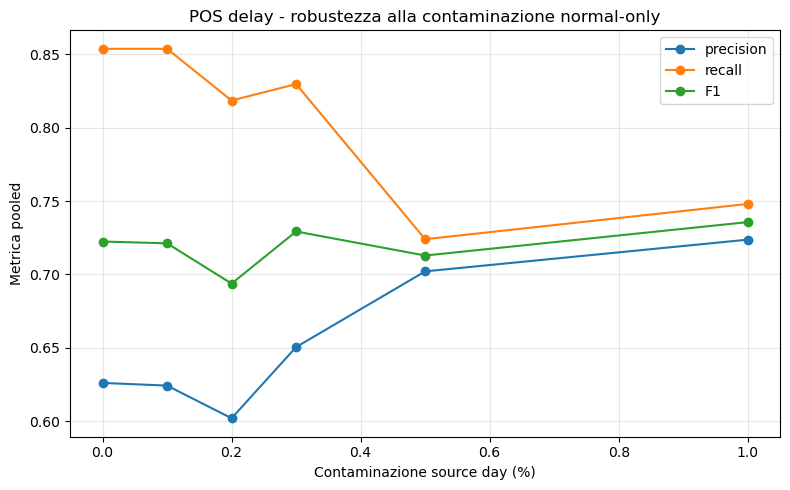

In [17]:
plot_df = pooled_summary.sort_values("contamination_percent").copy()

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["contamination_percent"],
    plot_df["precision_pooled"],
    marker="o",
    label="precision",
)
plt.plot(
    plot_df["contamination_percent"],
    plot_df["recall_pooled"],
    marker="o",
    label="recall",
)
plt.plot(
    plot_df["contamination_percent"],
    plot_df["f1_pooled"],
    marker="o",
    label="F1",
)
plt.xlabel("Contaminazione source day (%)")
plt.ylabel("Metrica pooled")
plt.title("POS delay - robustezza alla contaminazione normal-only")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pos_delay_contamination_precision_recall_f1_mad.png", dpi=150)
plt.show()

## Grafico F1 per tipo di delay

Visualizza la robustezza separatamente per tipo di POS delay.

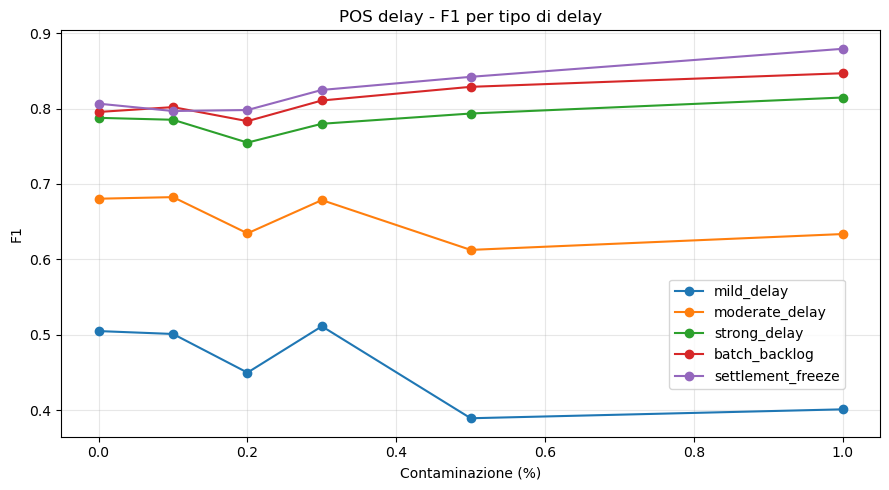

C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\figures


In [18]:
delay_type_order = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

plt.figure(figsize=(9, 5))

for delay_type in delay_type_order:
    g = (
        delay_type_summary[
            delay_type_summary["delay_type_dataset"] == delay_type
        ]
        .sort_values("contamination_percent")
    )

    if g.empty:
        continue

    plt.plot(
        g["contamination_percent"],
        g["f1_pooled"],
        marker="o",
        label=delay_type,
    )

plt.xlabel("Contaminazione (%)")
plt.ylabel("F1")
plt.title("POS delay - F1 per tipo di delay")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower center", bbox_to_anchor=(0.85, 0.10))
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "pos_delay_contamination_f1_by_delay_type_mad.png",
    dpi=150,
)
plt.show()
print(FIGURES_DIR)

## Output finali

Stampa i path principali generati dal notebook.

In [19]:
print("Output directory:", OUTPUT_DIR)
print("Raw results:", RAW_RESULTS_PATH)
print("Pooled summary:", POOLED_SUMMARY_PATH)
print("Delay type summary:", DELAY_TYPE_SUMMARY_PATH)
print("Threshold summary:", THRESHOLD_SUMMARY_PATH)
print("Training summary:", TRAINING_SUMMARY_PATH)

Output directory: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness
Raw results: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\pos_delay_contamination_raw_mad.csv
Pooled summary: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\tables\pos_delay_contamination_pooled_mad.csv
Delay type summary: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\tables\pos_delay_contamination_by_delay_type_pooled_mad.csv
Threshold summary: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\tables\pos_delay_contamination_threshold_summary_mad.csv
Training summary: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\contamination_robustness\tables\pos_delay_contamination_training_summary_mad.csv
